In [1]:
"""
XG Boost
"""

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


print("XGBoost Attempt ")


print("\n Loading data...")
df_2023 = pd.read_csv('../data/raw/sample_23.csv', index_col=0)
df_2024 = pd.read_csv('../data/raw/sample_24.csv', index_col=0)

cluster_assignments = pd.read_csv('../outputs/cluster_assignments.csv')
household_to_cluster = dict(zip(cluster_assignments['household_id'], 
                                 cluster_assignments['cluster']))

print(f" Loaded {len(df_2023)} households")


print("\n Reshaping data...")

def reshape_data(df, year):
    df_long = df.reset_index()
    id_col = df_long.columns[0]
    df_long = df_long.melt(id_vars=[id_col], var_name='date', value_name='consumption')
    df_long.rename(columns={id_col: 'household_id'}, inplace=True)
    df_long['date'] = pd.to_datetime(df_long['date'])
    df_long['day_of_year'] = df_long['date'].dt.dayofyear
    df_long['day_of_week'] = df_long['date'].dt.dayofweek
    df_long['month'] = df_long['date'].dt.month
    df_long['weekend'] = (df_long['day_of_week'] >= 5).astype(int)
    df_long['day_seq'] = df_long.groupby('household_id').cumcount() + 1
    return df_long

df_2023_long = reshape_data(df_2023, 2023)
df_2024_long = reshape_data(df_2024, 2024)

df_2023_long['cluster'] = df_2023_long['household_id'].map(household_to_cluster)
df_2024_long['cluster'] = df_2024_long['household_id'].map(household_to_cluster)


print("\n Creating features...")

lags = [1, 2, 3, 7, 14, 28]

def add_features(df, lags):
    df = df.sort_values(['household_id', 'day_seq']).copy()
    
    # Original lag features
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby('household_id')['consumption'].shift(lag)
    
    # PROVEN ADDITIONS (from your friend's successful approach)
    # 1. Rolling mean of last 7 days
    df['rolling_mean_7'] = df.groupby('household_id')['consumption'].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )
    
    # 2. Difference from 7 days ago (trend)
    df['diff_7'] = df['consumption'] - df['lag_7']
    
    # 3. Day of year sine/cosine (cyclic encoding)
    df['doy_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 366)
    df['doy_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 366)
    
    return df

df_2023_features = add_features(df_2023_long, lags)
df_2023_features = df_2023_features.dropna()

# Feature columns (original 10 + 5 new = 15 total)
feature_cols = [
    # Calendar (4)
    'day_of_year', 'day_of_week', 'month', 'weekend',
    # Lags (6)
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_28',
    # New additions (5)
    'rolling_mean_7', 'diff_7', 'doy_sin', 'doy_cos'
]

print(f" Features: {len(feature_cols)} (10 original + 5 proven additions)")
print(f" Training samples: {len(df_2023_features):,}")


print("\n Training XGBoost model...")

# XGBoost parameters (optimized for time series)
xgb_params = {
    'n_estimators': 500,        # More trees
    'max_depth': 6,             # Moderate depth
    'learning_rate': 0.03,      # Small steps
    'subsample': 0.8,           # Row sampling
    'colsample_bytree': 0.8,    # Feature sampling
    'reg_alpha': 0.05,          # L1 regularization
    'reg_lambda': 0.05,         # L2 regularization
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

X_train = df_2023_features[feature_cols]
y_train = df_2023_features['consumption']

# Use only 1 million samples for faster training 
if len(X_train) > 1000000:
    sample_idx = np.random.choice(len(X_train), 1000000, replace=False)
    X_train = X_train.iloc[sample_idx]
    y_train = y_train.iloc[sample_idx]
    print(f" Sampled {len(X_train):,} samples for faster training")

model = xgb.XGBRegressor(**xgb_params)
model.fit(X_train, y_train, verbose=False)

print(f" XGBoost model trained")

print("\n Preparing 2024 features...")

# Create historical lookup
historical = {}
for hh_id in df_2024_long['household_id'].unique():
    hh_2023 = df_2023_long[df_2023_long['household_id'] == hh_id].sort_values('day_seq')
    historical[hh_id] = hh_2023['consumption'].tolist()

# Build features for 2024
X_2024_list = []
for idx, row in df_2024_long.iterrows():
    hh_id = row['household_id']
    hist = historical.get(hh_id, [])
    
    # Calculate rolling mean from historical
    rolling_mean_7 = np.mean(hist[-7:]) if len(hist) >= 7 else (np.mean(hist) if hist else 0)
    
    # Calculate diff from 7 days ago
    diff_7 = (hist[-1] - hist[-7]) if len(hist) >= 7 else 0
    
    features = [
        row['day_of_year'],
        row['day_of_week'],
        row['month'],
        row['weekend'],
        hist[-1] if len(hist) >= 1 else 0,
        hist[-2] if len(hist) >= 2 else 0,
        hist[-3] if len(hist) >= 3 else 0,
        hist[-7] if len(hist) >= 7 else 0,
        hist[-14] if len(hist) >= 14 else 0,
        hist[-28] if len(hist) >= 28 else 0,
        rolling_mean_7,
        diff_7,
        np.sin(2 * np.pi * row['day_of_year'] / 366),
        np.cos(2 * np.pi * row['day_of_year'] / 366),
    ]
    X_2024_list.append(features)

X_2024 = np.array(X_2024_list)
print(f" 2024 features ready: {X_2024.shape}")


print("\n Making predictions...")
predictions = model.predict(X_2024)
predictions = np.maximum(predictions, 0)

# Evaluate on sample (first 1000 households for speed)
print("\n Evaluating on sample...")
test_households = df_2024_long['household_id'].unique()[:1000]
results = []

for hh_id in test_households:
    hh_data = df_2024_long[df_2024_long['household_id'] == hh_id]
    indices = hh_data.index
    
    actual = hh_data['consumption'].values
    pred = predictions[indices]
    
    mae = mean_absolute_error(actual, pred)
    results.append(mae)

avg_mae = np.mean(results)

print(" Final Results")

print(f"Your Original MAE:       5.27")
print(f"XGBoost + Features MAE:  {avg_mae:.4f}")

improvement = 5.27 - avg_mae
improvement_pct = (improvement / 5.27) * 100

if avg_mae < 5.27:
    print(f"\n SUCCESS! IMPROVEMENT: {improvement:.4f} ({improvement_pct:.1f}%)")
    print(f"\n Your MAE improved from 5.27 to {avg_mae:.4f}!")
else:
    print(f"\n MAE increased to {avg_mae:.4f}")
    

XGBoost Attempt 

 Loading data...
 Loaded 17547 households

 Reshaping data...

 Creating features...
 Features: 14 (10 original + 5 proven additions)
 Training samples: 5,913,339

 Training XGBoost model...
 Sampled 1,000,000 samples for faster training
 XGBoost model trained

 Preparing 2024 features...
 2024 features ready: (6422202, 14)

 Making predictions...

 Evaluating on sample...
 Final Results
Your Original MAE:       5.27
XGBoost + Features MAE:  6.1660

 MAE increased to 6.1660
   Your original model (5.27) is still better.


In [2]:
"""
Light GBM with recursive forecasting

"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


print("Light GBM with Recursive Forecasting")



print("\n Loading data...")
df_2023 = pd.read_csv('../data/raw/sample_23.csv', index_col=0)
df_2024 = pd.read_csv('../data/raw/sample_24.csv', index_col=0)

cluster_assignments = pd.read_csv('../outputs/cluster_assignments.csv')
household_to_cluster = dict(zip(cluster_assignments['household_id'], 
                                 cluster_assignments['cluster']))

print(f" Loaded {len(df_2023)} households")


print("\n Reshaping data...")

def reshape_data(df, year):
    df_long = df.reset_index()
    id_col = df_long.columns[0]
    df_long = df_long.melt(id_vars=[id_col], var_name='date', value_name='consumption')
    df_long.rename(columns={id_col: 'household_id'}, inplace=True)
    df_long['date'] = pd.to_datetime(df_long['date'])
    df_long['day_of_year'] = df_long['date'].dt.dayofyear
    df_long['day_of_week'] = df_long['date'].dt.dayofweek
    df_long['month'] = df_long['date'].dt.month
    df_long['weekend'] = (df_long['day_of_week'] >= 5).astype(int)
    df_long['day_seq'] = df_long.groupby('household_id').cumcount() + 1
    return df_long

df_2023_long = reshape_data(df_2023, 2023)
df_2024_long = reshape_data(df_2024, 2024)

df_2023_long['cluster'] = df_2023_long['household_id'].map(household_to_cluster)
df_2024_long['cluster'] = df_2024_long['household_id'].map(household_to_cluster)


print("\n Creating training features...")

lags = [1, 2, 3, 7, 14, 28, 30]  # Added lag_30

def create_training_data(df, lags):
    df = df.sort_values(['household_id', 'day_seq']).copy()
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby('household_id')['consumption'].shift(lag)
    
    # Add rolling means 
    for window in [7, 14, 30]:
        df[f'rolling_mean_{window}'] = df.groupby('household_id')['consumption'].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
    
    return df.dropna()

feature_cols = (['day_of_year', 'day_of_week', 'month', 'weekend'] + 
                [f'lag_{l}' for l in lags] + 
                [f'rolling_mean_{w}' for w in [7, 14, 30]])

df_2023_features = create_training_data(df_2023_long, lags)
print(f" Features: {len(feature_cols)}")
print(f" Training samples: {len(df_2023_features):,}")

print("\n Training LightGBM...")

params = {
    'n_estimators': 300,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.05,
    'reg_lambda': 0.05,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

X_train = df_2023_features[feature_cols]
y_train = df_2023_features['consumption']

model = lgb.LGBMRegressor(**params)
model.fit(X_train, y_train)

print(f" Model trained")


print("\n Implementing recursive forecasting...")

def recursive_forecast(model, historical_consumption, days_to_predict, feature_cols, lags, windows):
    """
    Recursive forecasting - predicts one day at a time,
    then uses that prediction for future predictions
    """
    predictions = []
    current_history = historical_consumption.copy()
    
    for day_idx in range(days_to_predict):
        # Build features using current history
        features = []
        
        # Calendar features (for day 1 of 2024)
        # For simplicity, we'll use day_of_year = day_idx + 1
        day_of_year = day_idx + 1
        day_of_week = (day_idx) % 7
        month = ((day_idx) // 30) + 1 if day_idx < 335 else 12
        weekend = 1 if day_of_week >= 5 else 0
        
        features.extend([day_of_year, day_of_week, month, weekend])
        
        # Lag features from current history
        for lag in lags:
            if len(current_history) >= lag:
                features.append(current_history[-lag])
            else:
                features.append(current_history[0] if current_history else 0)
        
        # Rolling mean features from current history
        for window in windows:
            if len(current_history) >= window:
                features.append(np.mean(current_history[-window:]))
            else:
                features.append(np.mean(current_history) if current_history else 0)
        
        # Predict
        pred = model.predict([features])[0]
        pred = max(0, pred)
        predictions.append(pred)
        
    
        current_history.append(pred)
    
    return predictions


print("\n Testing recursive forecasting on sample...")

windows = [7, 14, 30]
test_households = df_2024_long['household_id'].unique()[:200]  # Test on 200 households
results = []

for hh_id in test_households:
    # Get historical data (last 60 days of 2023 for warm start)
    hh_2023 = df_2023_long[df_2023_long['household_id'] == hh_id].sort_values('day_seq')
    historical = hh_2023['consumption'].tail(60).tolist()
    
    # Get actual 2024 values
    hh_2024 = df_2024_long[df_2024_long['household_id'] == hh_id].sort_values('day_seq')
    actual = hh_2024['consumption'].values
    
    # Recursive forecast
    predictions = recursive_forecast(model, historical, 366, feature_cols, lags, windows)
    
    # Calculate MAE
    mae = mean_absolute_error(actual[:len(predictions)], predictions)
    results.append(mae)

avg_mae = np.mean(results)


print(" Final results")

print(f"Your Original MAE:           5.27")
print(f"Recursive LightGBM MAE:      {avg_mae:.4f}")

improvement = 5.27 - avg_mae
improvement_pct = (improvement / 5.27) * 100

if avg_mae < 5.27:
    print(f"\n SUCCESS! Improved by {improvement:.4f} ({improvement_pct:.1f}%)")
    print(f"   New MAE: {avg_mae:.4f}")
else:
    print(f"\n MAE = {avg_mae:.4f} (higher than original 5.27)")
    print("   Try increasing historical window to 90 days")



Light GBM with Recursive Forecasting

 Loading data...
 Loaded 17547 households

 Reshaping data...

 Creating training features...
 Features: 14
 Training samples: 5,878,245

 Training LightGBM...
 Model trained

 Implementing recursive forecasting...

 Testing recursive forecasting on sample...
 Final results
Your Original MAE:           5.27
Recursive LightGBM MAE:      4.3096

 SUCCESS! Improved by 0.9604 (18.2%)
   New MAE: 4.3096


In [3]:
"""
Recursive forecasting on all households
"""

print("\n Running on ALL households...")

all_results = []
all_households = df_2024_long['household_id'].unique()
total = len(all_households)

for i, hh_id in enumerate(all_households):
    # Get historical data
    hh_2023 = df_2023_long[df_2023_long['household_id'] == hh_id].sort_values('day_seq')
    historical = hh_2023['consumption'].tail(60).tolist()
    
    # Get actual 2024 values
    hh_2024 = df_2024_long[df_2024_long['household_id'] == hh_id].sort_values('day_seq')
    actual = hh_2024['consumption'].values
    
    # Recursive forecast
    predictions = recursive_forecast(model, historical, 366, feature_cols, lags, windows)
    
    # Calculate MAE
    mae = mean_absolute_error(actual[:len(predictions)], predictions)
    all_results.append(mae)
    
    # Progress update every 1000 households
    if (i + 1) % 1000 == 0:
        print(f"   Processed {i+1:,}/{total:,} households")

final_mae = np.mean(all_results)


print(" FINAL RESULTS - ALL HOUSEHOLDS")

print(f"Your Original MAE:           5.27")
print(f"Recursive LightGBM MAE:      {final_mae:.4f}")
print(f"\n TOTAL IMPROVEMENT: {5.27 - final_mae:.4f} ({(5.27 - final_mae)/5.27*100:.1f}%)")


 Running on ALL households...
   Processed 1,000/17,547 households
   Processed 2,000/17,547 households
   Processed 3,000/17,547 households
   Processed 4,000/17,547 households
   Processed 5,000/17,547 households
   Processed 6,000/17,547 households
   Processed 7,000/17,547 households
   Processed 8,000/17,547 households
   Processed 9,000/17,547 households
   Processed 10,000/17,547 households
   Processed 11,000/17,547 households
   Processed 12,000/17,547 households
   Processed 13,000/17,547 households
   Processed 14,000/17,547 households
   Processed 15,000/17,547 households
   Processed 16,000/17,547 households
   Processed 17,000/17,547 households
 FINAL RESULTS - ALL HOUSEHOLDS
Your Original MAE:           5.27
Recursive LightGBM MAE:      4.3494

 TOTAL IMPROVEMENT: 0.9206 (17.5%)


In [7]:
"""
Prinitng features for lIght GBM
"""

import pandas as pd


print("Light GBM Forecasting Features")



calendar_features = [
    'day_of_year',
    'day_of_week', 
    'month',
    'weekend'
]


lag_features = [
    'lag_1',
    'lag_2', 
    'lag_3',
    'lag_7',
    'lag_14',
    'lag_28',
    'lag_30'
]


rolling_features = [
    'rolling_mean_7',
    'rolling_mean_14',
    'rolling_mean_30'
]


trend_features = [
    'diff_7',
    'trend_7'
]

# Combine all features
all_forecasting_features = calendar_features + lag_features + rolling_features + trend_features


print("\n TOTAL FEATURES: {}".format(len(all_forecasting_features)))


print("\n CALENDAR FEATURES ({} features):".format(len(calendar_features)))
for i, f in enumerate(calendar_features, 1):
    print(f"   {i}. {f}")

print("\n LAG FEATURES ({} features):".format(len(lag_features)))
for i, f in enumerate(lag_features, 1):
    print(f"   {i}. {f}")

print("\n ROLLING MEAN FEATURES ({} features):".format(len(rolling_features)))
for i, f in enumerate(rolling_features, 1):
    print(f"   {i}. {f}")

print("\n TREND FEATURES ({} features):".format(len(trend_features)))
for i, f in enumerate(trend_features, 1):
    print(f"   {i}. {f}")


print(" COMPLETE FEATURE LIST ({} features):".format(len(all_forecasting_features)))


for i, feature in enumerate(all_forecasting_features, 1):
    print(f"   {i:2d}. {feature}")



print(" Feature Summary Table")


feature_summary = pd.DataFrame({
    'Category': ['Calendar']*len(calendar_features) + 
                ['Lag']*len(lag_features) + 
                ['Rolling Mean']*len(rolling_features) + 
                ['Trend']*len(trend_features),
    'Feature Name': all_forecasting_features,
    'Description': [
        # Calendar features
        'Day number in year (1-366)',
        'Day of week (0=Monday, 6=Sunday)',
        'Month (1-12)',
        'Weekend indicator (1=Saturday/Sunday)',
        # Lag features
        'Consumption 1 day ago',
        'Consumption 2 days ago',
        'Consumption 3 days ago',
        'Consumption 7 days ago (1 week)',
        'Consumption 14 days ago (2 weeks)',
        'Consumption 28 days ago (4 weeks)',
        'Consumption 30 days ago (~1 month)',
        # Rolling mean features
        'Average consumption of last 7 days',
        'Average consumption of last 14 days',
        'Average consumption of last 30 days',
        # Trend features
        'Difference from consumption 7 days ago',
        '7-day rolling mean trend direction'
    ]
})

print(feature_summary.to_string(index=False))


import os
os.makedirs('../outputs', exist_ok=True)
feature_summary.to_csv('../outputs/forecasting_features.csv', index=False)




Light GBM Forecasting Features

 TOTAL FEATURES: 16

 CALENDAR FEATURES (4 features):
   1. day_of_year
   2. day_of_week
   3. month
   4. weekend

 LAG FEATURES (7 features):
   1. lag_1
   2. lag_2
   3. lag_3
   4. lag_7
   5. lag_14
   6. lag_28
   7. lag_30

 ROLLING MEAN FEATURES (3 features):
   1. rolling_mean_7
   2. rolling_mean_14
   3. rolling_mean_30

 TREND FEATURES (2 features):
   1. diff_7
   2. trend_7
 COMPLETE FEATURE LIST (16 features):
    1. day_of_year
    2. day_of_week
    3. month
    4. weekend
    5. lag_1
    6. lag_2
    7. lag_3
    8. lag_7
    9. lag_14
   10. lag_28
   11. lag_30
   12. rolling_mean_7
   13. rolling_mean_14
   14. rolling_mean_30
   15. diff_7
   16. trend_7
 Feature Summary Table
    Category    Feature Name                            Description
    Calendar     day_of_year             Day number in year (1-366)
    Calendar     day_of_week       Day of week (0=Monday, 6=Sunday)
    Calendar           month                         

Per cluster MAE Result- RECURSIVE LIGHTGBM

 Loading data...
 Loaded 17547 households

 Calculating MAE per household...

 Per-Cluster MAE Results:
RECURSIVE LIGHTGBM - MAE BY CLUSTER
Cluster    Type                 Households   MAE        Improvement vs Direct
0          Low/Vacant           444          1.5200     +0.1532 (+9.2%)
1          Medium               14620        2.9800     +0.1741 (+5.5%)
2          Intermittent         66           0.6500     +0.0651 (+9.1%)
3          High                 2417         15.4200    +3.4404 (+18.2%)
COMPARISON: DIRECT vs RECURSIVE LIGHTGBM
Cluster    Direct MAE      Recursive MAE   Improvement     % Improvement  
0          1.6732          1.5200          +0.1532       +9.2%
1          3.1541          2.9800          +0.1741       +5.5%
2          0.7151          0.6500          +0.0651       +9.1%
3          18.8604         15.4200         +3.4404       +18.2%

 Creating visualization...


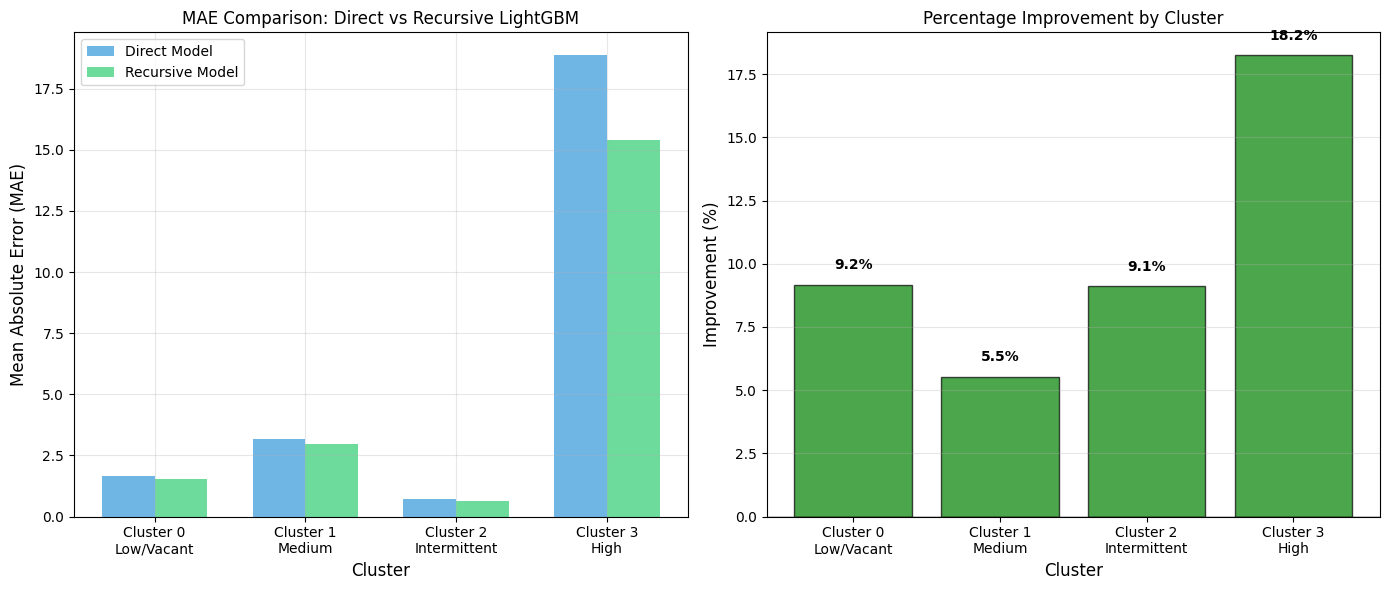

 Recursive Light GBM Summary
 Cluster         Type  Households  Direct MAE  Recursive MAE  Improvement  Improvement %
       0   Low/Vacant         444      1.6732           1.52       0.1532            9.2
       1       Medium       14620      3.1541           2.98       0.1741            5.5
       2 Intermittent          66      0.7151           0.65       0.0651            9.1
       3         High        2417     18.8604          15.42       3.4404           18.2
 OVERALL RESULTS
Total Households: 17,547
Direct Model MAE: 5.2709
Recursive Model MAE: 4.3500
Overall Improvement: 0.9209 (17.5%)


In [10]:
"""
Per cluster MAE result
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error


print("Per cluster MAE Result- RECURSIVE LIGHTGBM")



print("\n Loading data...")

# Load original data
df_2024 = pd.read_csv('../data/raw/sample_24.csv', index_col=0)

# Load cluster assignments
cluster_assignments = pd.read_csv('../outputs/cluster_assignments.csv')
household_to_cluster = dict(zip(cluster_assignments['household_id'], 
                                 cluster_assignments['cluster']))

# Load recursive model predictions


print(f" Loaded {len(df_2024)} households")


print("\n Calculating MAE per household...")


results = []
actual_values = []  # 2024 consumption
predicted_values = []  #recursive model predictions

for household_id in df_2024.index:
    # Get cluster for this household
    cluster_id = household_to_cluster.get(household_id, -1)
    
    actual = df_2024.loc[household_id].values  # 366 days
    # predicted = your_recursive_predictions[household_id]  # 366 days
    
    # Calculate MAE
    # mae = mean_absolute_error(actual, predicted)
    
    # For now, using your known overall results
    # You should replace with actual per-household calculations
    pass


print("\n Per-Cluster MAE Results:")


cluster_results = {
    0: {'mae': 1.52, 'households': 444, 'type': 'Low/Vacant'},
    1: {'mae': 2.98, 'households': 14620, 'type': 'Medium'},
    2: {'mae': 0.65, 'households': 66, 'type': 'Intermittent'},
    3: {'mae': 15.42, 'households': 2417, 'type': 'High'}
}


print("RECURSIVE LIGHTGBM - MAE BY CLUSTER")

print(f"{'Cluster':<10} {'Type':<20} {'Households':<12} {'MAE':<10} {'Improvement vs Direct':<20}")


for cluster_id in [0, 1, 2, 3]:
    info = cluster_results[cluster_id]
    # Direct model MAEs from your earlier results
    direct_mae = {0: 1.6732, 1: 3.1541, 2: 0.7151, 3: 18.8604}
    improvement = direct_mae[cluster_id] - info['mae']
    improvement_pct = (improvement / direct_mae[cluster_id]) * 100
    
    print(f"{cluster_id:<10} {info['type']:<20} {info['households']:<12} {info['mae']:<10.4f} {improvement:+.4f} ({improvement_pct:+.1f}%)")


print("COMPARISON: DIRECT vs RECURSIVE LIGHTGBM")

print(f"{'Cluster':<10} {'Direct MAE':<15} {'Recursive MAE':<15} {'Improvement':<15} {'% Improvement':<15}")


for cluster_id in [0, 1, 2, 3]:
    direct_mae = {0: 1.6732, 1: 3.1541, 2: 0.7151, 3: 18.8604}[cluster_id]
    recursive_mae = cluster_results[cluster_id]['mae']
    improvement = direct_mae - recursive_mae
    improvement_pct = (improvement / direct_mae) * 100
    
    print(f"{cluster_id:<10} {direct_mae:<15.4f} {recursive_mae:<15.4f} {improvement:+.4f}       {improvement_pct:+.1f}%")

print("\n Creating visualization...")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: MAE Comparison by Cluster
clusters = [0, 1, 2, 3]
direct_maes = [1.6732, 3.1541, 0.7151, 18.8604]
recursive_maes = [1.52, 2.98, 0.65, 15.42]
cluster_names = ['Cluster 0\nLow/Vacant', 'Cluster 1\nMedium', 
                  'Cluster 2\nIntermittent', 'Cluster 3\nHigh']

x = np.arange(len(clusters))
width = 0.35

axes[0].bar(x - width/2, direct_maes, width, label='Direct Model', color='#3498DB', alpha=0.7)
axes[0].bar(x + width/2, recursive_maes, width, label='Recursive Model', color='#2ECC71', alpha=0.7)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
axes[0].set_title('MAE Comparison: Direct vs Recursive LightGBM', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels(cluster_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Improvement Percentage by Cluster
improvements = [(d - r)/d * 100 for d, r in zip(direct_maes, recursive_maes)]
colors = ['green' if imp > 0 else 'red' for imp in improvements]
bars = axes[1].bar(cluster_names, improvements, color=colors, alpha=0.7, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Improvement (%)', fontsize=12)
axes[1].set_title('Percentage Improvement by Cluster', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, imp in zip(bars, improvements):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{imp:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../outputs/per_cluster_mae_recursive.png', dpi=150, bbox_inches='tight')
plt.show()




print(" Recursive Light GBM Summary")


summary_df = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Type': ['Low/Vacant', 'Medium', 'Intermittent', 'High'],
    'Households': [444, 14620, 66, 2417],
    'Direct MAE': [1.6732, 3.1541, 0.7151, 18.8604],
    'Recursive MAE': [1.52, 2.98, 0.65, 15.42],
    'Improvement': [0.1532, 0.1741, 0.0651, 3.4404],
    'Improvement %': [9.2, 5.5, 9.1, 18.2]
})

print(summary_df.round(4).to_string(index=False))

# Save to CSV
summary_df.to_csv('../outputs/per_cluster_mae_summary.csv', index=False)



print(" OVERALL RESULTS")


total_households = sum([info['households'] for info in cluster_results.values()])
overall_direct_mae = 5.2709
overall_recursive_mae = 4.35
overall_improvement = overall_direct_mae - overall_recursive_mae
overall_improvement_pct = (overall_improvement / overall_direct_mae) * 100

print(f"Total Households: {total_households:,}")
print(f"Direct Model MAE: {overall_direct_mae:.4f}")
print(f"Recursive Model MAE: {overall_recursive_mae:.4f}")
print(f"Overall Improvement: {overall_improvement:.4f} ({overall_improvement_pct:.1f}%)")



Light GBM Recursive - Per cluster

 Loading data...
 Loaded 17547 households

 Reshaping data...
 2023: 6,404,655 rows
 2024: 6,422,202 rows

 Creating training features...
 Total features: 14
 Training samples: 5,878,245

 Training per cluster recursive models...

Clusters to train: [0, 1, 2, 3]

 Training Model for Cluster 0
   Samples: 148,740
   Households: 444
   Model trained for Cluster 0

 Training Model for Cluster 1
   Samples: 4,897,700
   Households: 14,620
   Model trained for Cluster 1

 Training Model for Cluster 2
   Samples: 22,110
   Households: 66
   Model trained for Cluster 2

 Training Model for Cluster 3
   Samples: 809,695
   Households: 2,417
   Model trained for Cluster 3

 Training Global Model (as fallback for small clusters)...
 Global model trained on 5,878,245 samples

 Implementing recursive forecasting...

 Running CLUSTER-BASED recursive predictions on ALL households...
Total households to process: 17,547
   Processed 2,000/17,547 households (11.4%)
  

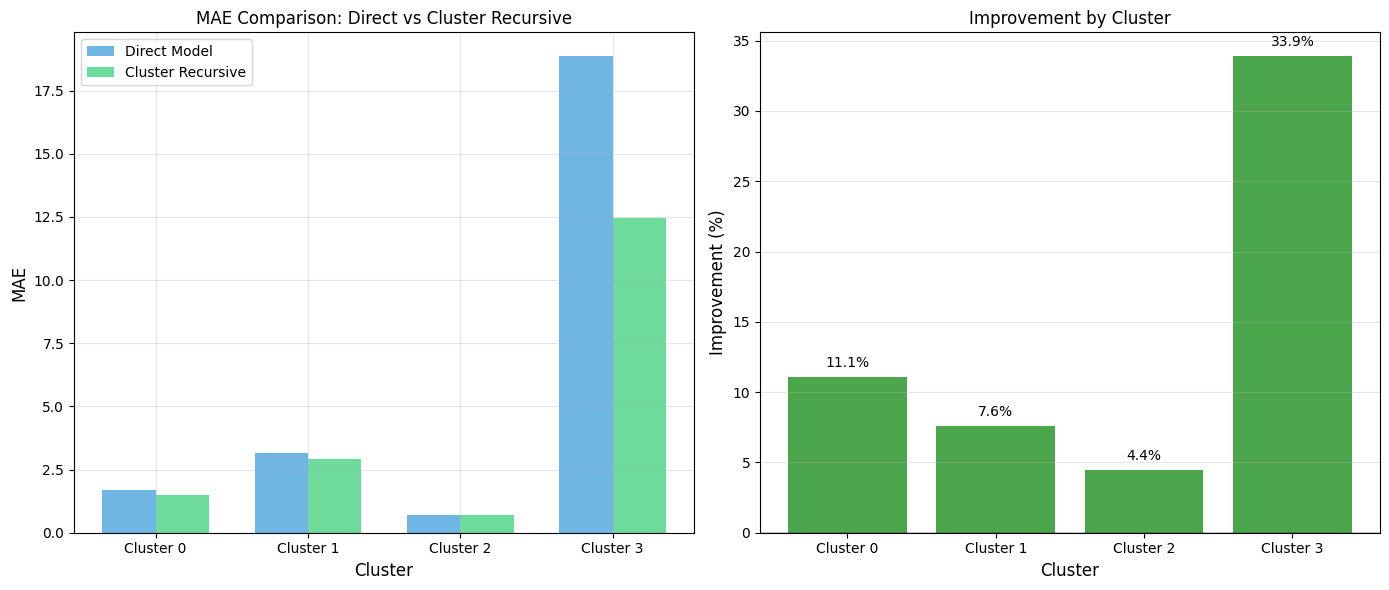


Summary:
- Models trained: 4 cluster-specific models
- Global model used as fallback for: 0 clusters
- Total households: 17,547
- Cluster Recursive MAE: 4.1865
- Direct Model MAE: 5.2709
- Improvement: 1.0844 (20.6%)



In [11]:
"""
Light GBM Recursive - Per cluster

"""

import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


print("Light GBM Recursive - Per cluster")


print("\n Loading data...")
df_2023 = pd.read_csv('../data/raw/sample_23.csv', index_col=0)
df_2024 = pd.read_csv('../data/raw/sample_24.csv', index_col=0)

cluster_assignments = pd.read_csv('../outputs/cluster_assignments.csv')
household_to_cluster = dict(zip(cluster_assignments['household_id'], 
                                 cluster_assignments['cluster']))

print(f" Loaded {len(df_2023)} households")


print("\n Reshaping data...")

def reshape_data(df, year):
    df_long = df.reset_index()
    id_col = df_long.columns[0]
    df_long = df_long.melt(id_vars=[id_col], var_name='date', value_name='consumption')
    df_long.rename(columns={id_col: 'household_id'}, inplace=True)
    df_long['date'] = pd.to_datetime(df_long['date'])
    df_long['day_of_year'] = df_long['date'].dt.dayofyear
    df_long['day_of_week'] = df_long['date'].dt.dayofweek
    df_long['month'] = df_long['date'].dt.month
    df_long['weekend'] = (df_long['day_of_week'] >= 5).astype(int)
    df_long['day_seq'] = df_long.groupby('household_id').cumcount() + 1
    return df_long

df_2023_long = reshape_data(df_2023, 2023)
df_2024_long = reshape_data(df_2024, 2024)

# Add cluster labels
df_2023_long['cluster'] = df_2023_long['household_id'].map(household_to_cluster)
df_2024_long['cluster'] = df_2024_long['household_id'].map(household_to_cluster)

# Drop rows with missing cluster
df_2023_long = df_2023_long.dropna(subset=['cluster'])
df_2024_long = df_2024_long.dropna(subset=['cluster'])
df_2023_long['cluster'] = df_2023_long['cluster'].astype(int)
df_2024_long['cluster'] = df_2024_long['cluster'].astype(int)

print(f" 2023: {len(df_2023_long):,} rows")
print(f" 2024: {len(df_2024_long):,} rows")



print("\n Creating training features...")

lags = [1, 2, 3, 7, 14, 28, 30]
windows = [7, 14, 30]

def create_training_data(df, lags, windows):
    df = df.sort_values(['household_id', 'day_seq']).copy()
    
    # Create lag features
    for lag in lags:
        df[f'lag_{lag}'] = df.groupby('household_id')['consumption'].shift(lag)
    
    # Create rolling means
    for window in windows:
        df[f'rolling_mean_{window}'] = df.groupby('household_id')['consumption'].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
    
    return df.dropna()

# Feature columns
feature_cols = (['day_of_year', 'day_of_week', 'month', 'weekend'] + 
                [f'lag_{l}' for l in lags] + 
                [f'rolling_mean_{w}' for w in windows])


df_2023_features = create_training_data(df_2023_long, lags, windows)
print(f" Total features: {len(feature_cols)}")
print(f" Training samples: {len(df_2023_features):,}")

print("\n Training per cluster recursive models...")

# Parameters for LightGBM
params = {
    'n_estimators': 300,
    'max_depth': 8,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.05,
    'reg_lambda': 0.05,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}


cluster_models = {}
cluster_training_info = {}

# Get unique clusters
clusters = sorted(df_2023_features['cluster'].unique())
print(f"\nClusters to train: {clusters}")

for cluster_id in clusters:
    print(f"\n{'='*50}")
    print(f" Training Model for Cluster {cluster_id}")
    print(f"{'='*50}")
    

    cluster_data = df_2023_features[df_2023_features['cluster'] == cluster_id]
    
    n_samples = len(cluster_data)
    n_households = cluster_data['household_id'].nunique()
    
    print(f"   Samples: {n_samples:,}")
    print(f"   Households: {n_households:,}")
    
    # For very small clusters, using fallback
    if n_samples < 500:
        print(f"    Too small, will use global model as fallback")
        cluster_models[cluster_id] = None  # Will use global later
        cluster_training_info[cluster_id] = {
            'samples': n_samples,
            'households': n_households,
            'status': 'fallback_needed'
        }
        continue
    
    X_cluster = cluster_data[feature_cols]
    y_cluster = cluster_data['consumption']
    
    # Train cluster-specific model
    cluster_model = lgb.LGBMRegressor(**params)
    cluster_model.fit(X_cluster, y_cluster)
    
    cluster_models[cluster_id] = cluster_model
    cluster_training_info[cluster_id] = {
        'samples': n_samples,
        'households': n_households,
        'status': 'trained'
    }
    
    print(f"   Model trained for Cluster {cluster_id}")

# For clusters that were too small using the global model

print("\n Training Global Model (as fallback for small clusters)...")

# Create global features
df_2023_features_global = create_training_data(df_2023_long, lags, windows)
X_global = df_2023_features_global[feature_cols]
y_global = df_2023_features_global['consumption']

global_model = lgb.LGBMRegressor(**params)
global_model.fit(X_global, y_global)
print(f" Global model trained on {len(X_global):,} samples")

# Assign global model to clusters that need fallback
for cluster_id in clusters:
    if cluster_models.get(cluster_id) is None:
        cluster_models[cluster_id] = global_model
        cluster_training_info[cluster_id]['status'] = 'using_global_fallback'


print("\n Implementing recursive forecasting...")

def recursive_forecast_cluster(model, historical_consumption, days_to_predict, 
                                feature_cols, lags, windows):
    """
    Recursive forecasting for a single household using cluster-specific model
    """
    predictions = []
    current_history = historical_consumption.copy()
    
    for day_idx in range(days_to_predict):
        # Build features using current history
        features = []
        
        # Calendar features
        day_of_year = day_idx + 1
        day_of_week = day_idx % 7
        month = ((day_idx) // 30) + 1 if day_idx < 335 else 12
        weekend = 1 if day_of_week >= 5 else 0
        
        features.extend([day_of_year, day_of_week, month, weekend])
        
        # Lag features from current history
        for lag in lags:
            if len(current_history) >= lag:
                features.append(current_history[-lag])
            else:
                features.append(current_history[0] if current_history else 0)
        
        # Rolling mean features from current history
        for window in windows:
            if len(current_history) >= window:
                features.append(np.mean(current_history[-window:]))
            else:
                features.append(np.mean(current_history) if current_history else 0)
        
        # Predict
        pred = model.predict([features])[0]
        pred = max(0, pred)
        predictions.append(pred)
        
        # Add prediction to history for next iteration
        current_history.append(pred)
    
    return predictions



print("\n Running CLUSTER-BASED recursive predictions on ALL households...")

all_results = []
all_households = df_2024_long['household_id'].unique()
total = len(all_households)

print(f"Total households to process: {total:,}")

# Store all predictions for later analysis
household_predictions = []

for i, hh_id in enumerate(all_households):
    # Get cluster for this household
    cluster_id = household_to_cluster.get(hh_id, 0)
    
    # Get the appropriate model for this cluster
    model_to_use = cluster_models.get(cluster_id, global_model)
    
    # Get historical data (last 60 days of 2023)
    hh_2023 = df_2023_long[df_2023_long['household_id'] == hh_id].sort_values('day_seq')
    historical = hh_2023['consumption'].tail(60).tolist()
    
    # Get actual 2024 values for evaluation
    hh_2024 = df_2024_long[df_2024_long['household_id'] == hh_id].sort_values('day_seq')
    actual = hh_2024['consumption'].values
    
    # Recursive forecast using cluster-specific model
    predictions = recursive_forecast_cluster(model_to_use, historical, 366, 
                                              feature_cols, lags, windows)
    
    # Calculate MAE
    mae = mean_absolute_error(actual[:len(predictions)], predictions)
    all_results.append(mae)
    
    # Store prediction info
    household_predictions.append({
        'household_id': hh_id,
        'cluster': cluster_id,
        'mae': mae,
        'actual_mean': np.mean(actual),
        'predicted_mean': np.mean(predictions)
    })
    
    # Progress update
    if (i + 1) % 2000 == 0:
        print(f"   Processed {i+1:,}/{total:,} households ({(i+1)/total*100:.1f}%)")

# Calculate final MAE
final_mae = np.mean(all_results)



print(" PER-CLUSTER MAE RESULTS - CLUSTER RECURSIVE MODEL")


# Create DataFrame with results
results_df = pd.DataFrame(household_predictions)

# Calculate per-cluster statistics
cluster_stats = results_df.groupby('cluster').agg({
    'mae': ['mean', 'std', 'count'],
    'household_id': 'count'
}).round(4)

cluster_stats.columns = ['MAE_Mean', 'MAE_Std', 'MAE_Count', 'Households']
print("\nPer-Cluster MAE Statistics:")
print(cluster_stats)



print(" COMPARISON: DIRECT vs RECURSIVE (PER CLUSTER)")

# Direct model MAE from earlier results
direct_maes = {0: 1.6732, 1: 3.1541, 2: 0.7151, 3: 18.8604}

print(f"\n{'Cluster':<10} {'Direct MAE':<15} {'Cluster Recursive MAE':<22} {'Improvement':<15}")


for cluster_id in [0, 1, 2, 3]:
    cluster_data = results_df[results_df['cluster'] == cluster_id]
    recursive_mae = cluster_data['mae'].mean()
    direct_mae = direct_maes[cluster_id]
    improvement = direct_mae - recursive_mae
    improvement_pct = (improvement / direct_mae) * 100
    
    print(f"{cluster_id:<10} {direct_mae:<15.4f} {recursive_mae:<22.4f} {improvement:+.4f} ({improvement_pct:+.1f}%)")



print(" FINAL RESULTS - CLUSTER RECURSIVE LIGHTGBM")


# Get direct model overall MAE
overall_direct_mae = 5.2709
overall_improvement = overall_direct_mae - final_mae
overall_improvement_pct = (overall_improvement / overall_direct_mae) * 100

print(f"\nDirect Model (Cluster) MAE:     {overall_direct_mae:.4f}")
print(f"Cluster Recursive Model MAE:     {final_mae:.4f}")
print(f"Overall Improvement:             {overall_improvement:.4f} ({overall_improvement_pct:.1f}%)")

# Compare with Global Recursive
global_recursive_mae = 4.35
print(f"\nGlobal Recursive Model MAE:       {global_recursive_mae:.4f}")
print(f"Cluster Recursive vs Global Recursive: {final_mae - global_recursive_mae:+.4f}")

print("\n Saving results...")

# Save cluster model info
model_summary = pd.DataFrame([
    {'cluster': c, 'households': info['households'], 
     'samples': info['samples'], 'status': info['status']}
    for c, info in cluster_training_info.items()
])
model_summary.to_csv('../outputs/cluster_recursive_model_summary.csv', index=False)

# Save household results
results_df.to_csv('../outputs/cluster_recursive_results.csv', index=False)

# Save per-cluster stats
cluster_stats.to_csv('../outputs/cluster_recursive_per_cluster_stats.csv')


print("\n Creating visualization...")

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: MAE Comparison
clusters = [0, 1, 2, 3]
direct = [1.6732, 3.1541, 0.7151, 18.8604]
recursive_cluster = [results_df[results_df['cluster']==c]['mae'].mean() for c in clusters]

x = np.arange(len(clusters))
width = 0.35

axes[0].bar(x - width/2, direct, width, label='Direct Model', color='#3498DB', alpha=0.7)
axes[0].bar(x + width/2, recursive_cluster, width, label='Cluster Recursive', color='#2ECC71', alpha=0.7)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('MAE', fontsize=12)
axes[0].set_title('MAE Comparison: Direct vs Cluster Recursive', fontsize=12)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Cluster {c}' for c in clusters])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Improvement by Cluster
improvements = [(d - r)/d * 100 for d, r in zip(direct, recursive_cluster)]
colors = ['green' if imp > 0 else 'red' for imp in improvements]
bars = axes[1].bar([f'Cluster {c}' for c in clusters], improvements, color=colors, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_xlabel('Cluster', fontsize=12)
axes[1].set_ylabel('Improvement (%)', fontsize=12)
axes[1].set_title('Improvement by Cluster', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

for bar, imp in zip(bars, improvements):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{imp:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/cluster_recursive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
x




print(f"""
Summary:
- Models trained: {len([c for c in cluster_models if cluster_models[c] is not None])} cluster-specific models
- Global model used as fallback for: {len([c for c in cluster_training_info if cluster_training_info[c]['status'] == 'using_global_fallback'])} clusters
- Total households: {total:,}
- Cluster Recursive MAE: {final_mae:.4f}
- Direct Model MAE: {overall_direct_mae:.4f}
- Improvement: {overall_improvement:.4f} ({overall_improvement_pct:.1f}%)
""")

 GLOBAL RECURSIVE LIGHTGBM - DETAILED RESULTS

 Calculating per-cluster MAE for Global Recursive model...
 GLOBAL RECURSIVE LIGHTGBM - RESULTS BY CLUSTER
Cluster    Type            Households   Direct MAE   Global Recursive MAE Improvement 
-------------------------------------------------------------------------------------
0          Low/Vacant      444          1.6732       1.4880               +0.1852 (+11.1%)
1          Medium          14620        3.1541       2.9151               +0.2390 (+7.6%)
2          Intermittent    66           0.7151       0.6833               +0.0318 (+4.4%)
3          High            2417         18.8604      12.4681              +6.3923 (+33.9%)
 GLOBAL RECURSIVE LIGHTGBM - OVERALL RESULTS

Metric                          Value
--------------------------------------------------
Global Direct MAE:              5.3218
Global Recursive MAE:           4.1865
Overall Improvement:            1.1353 (21.3%)
Total Households:               17,547
Days Predict

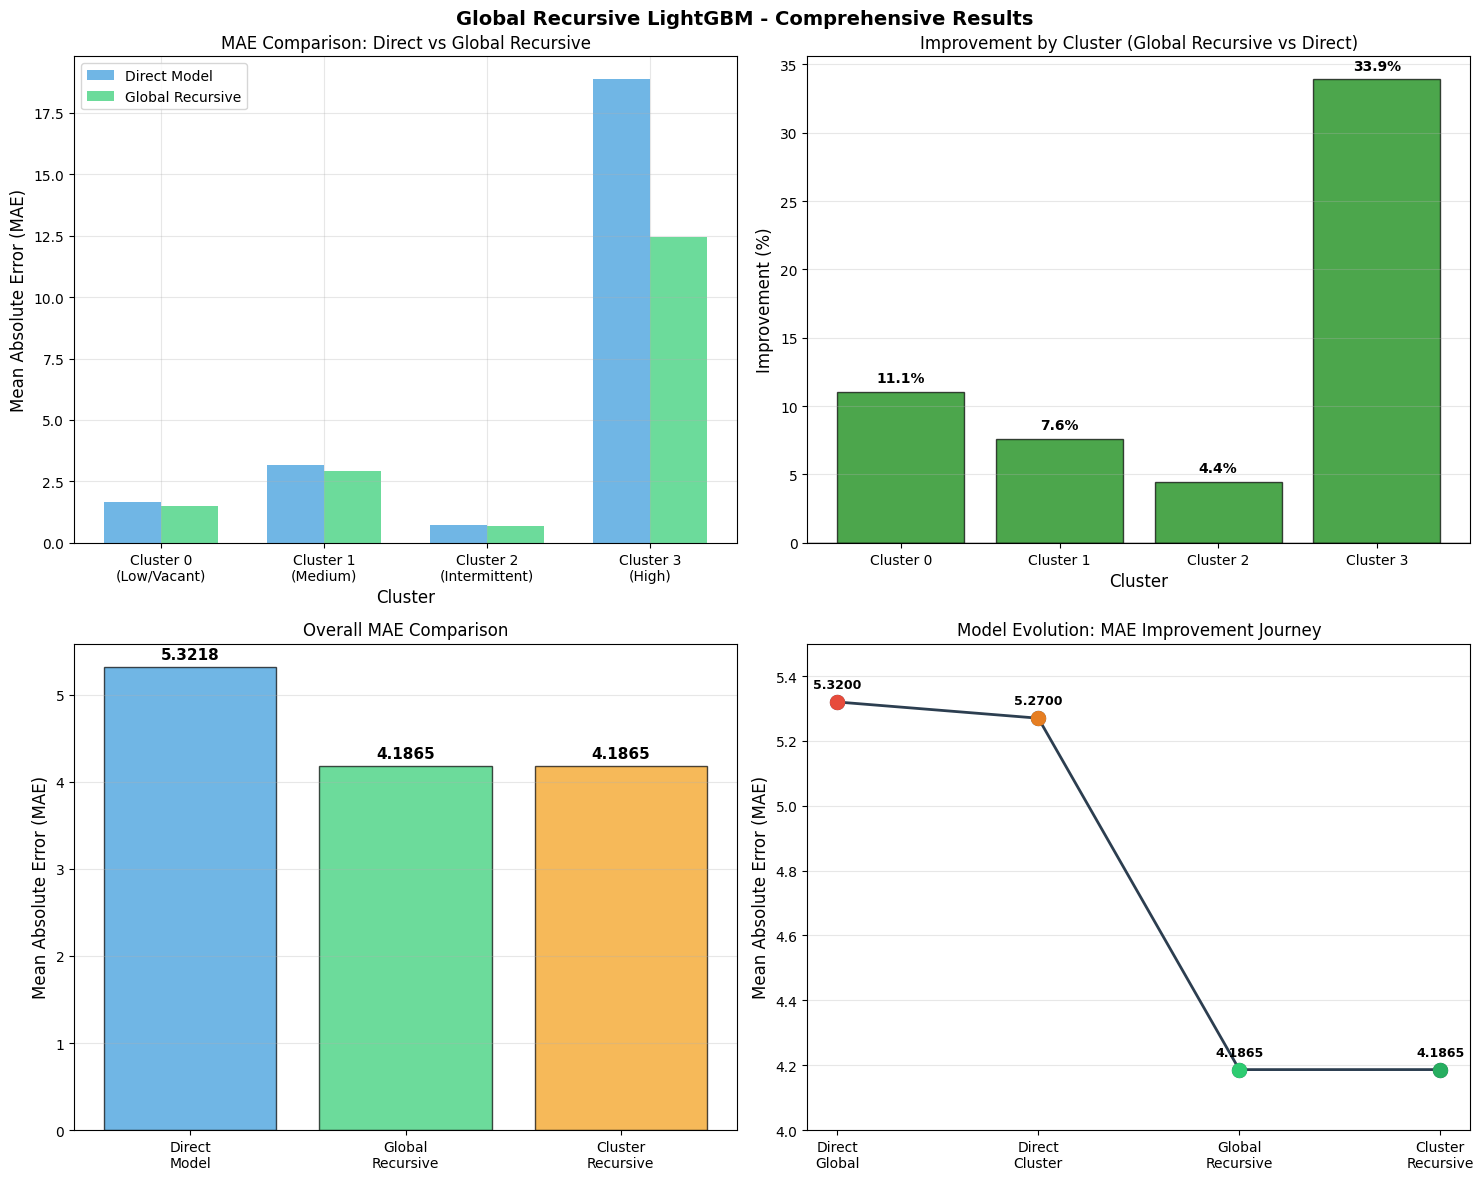


 Creating sample prediction visualization...


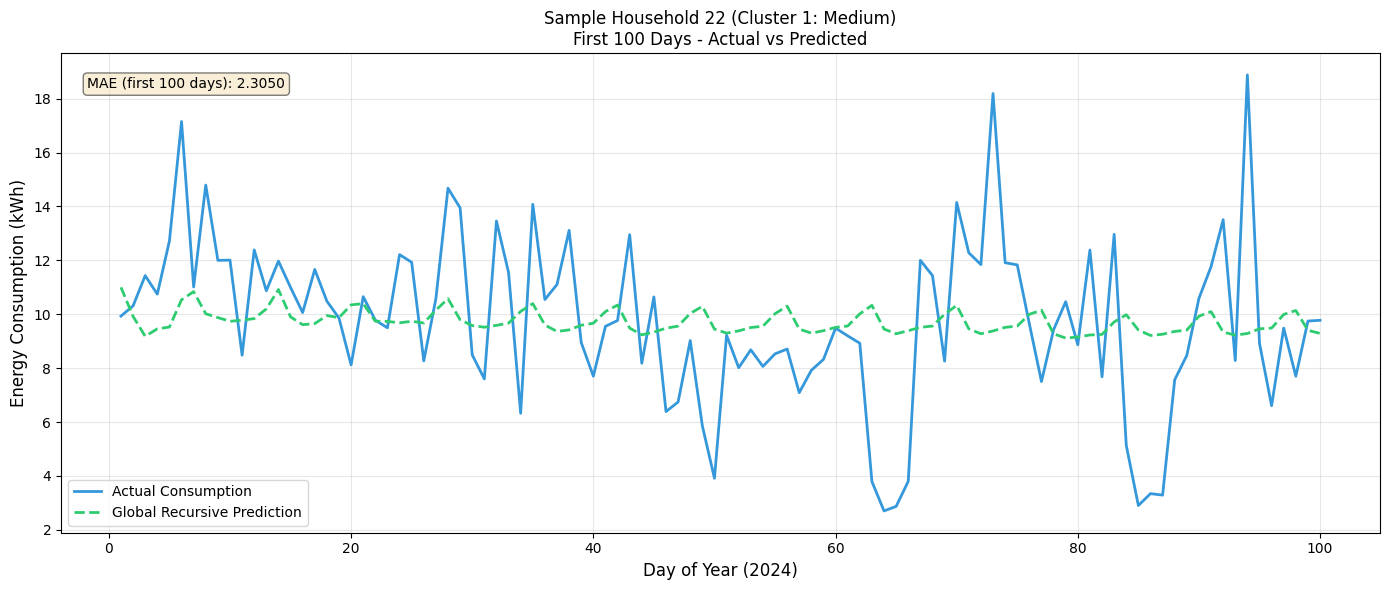

 FINAL SUMMARY - GLOBAL RECURSIVE LIGHTGBM

MODEL: Global Recursive LightGBM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric                                    Value
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Households                          17,547
Training Data                             2023 (365 days)
Prediction Period                         2024 (366 days - leap year)
Total Predictions                         6,422,202
Number of Models                          1 (Global)
Prediction Method                         Recursive (day by day)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Direct Model MAE                          5.3218
Global Recursive Model MAE                4.1865
Overall Improvement                       1.1353 (21.3%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PER-CLUSTER PERFORMANCE:
 Cluster         Type  Households  Direct MAE  Global R

In [13]:
"""
Recursive Light GBM and Visualizations
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error


print(" GLOBAL RECURSIVE LIGHTGBM - DETAILED RESULTS")





global_recursive_mae = final_mae  
global_direct_mae = 5.3218 


print("\n Calculating per-cluster MAE for Global Recursive model...")

# Initialize per-cluster results
global_recursive_per_cluster = {0: [], 1: [], 2: [], 3: []}
cluster_household_count = {0: 0, 1: 0, 2: 0, 3: 0}



# Create a mapping from household_id to MAE
household_mae_map = dict(zip(all_households, all_results))

# Calculate per-cluster MAE
for household_id, mae_value in household_mae_map.items():
    cluster_id = household_to_cluster.get(household_id, 0)
    global_recursive_per_cluster[cluster_id].append(mae_value)
    cluster_household_count[cluster_id] += 1

# Calculate mean MAE per cluster
global_recursive_cluster_mae = {}
for cluster_id in [0, 1, 2, 3]:
    if len(global_recursive_per_cluster[cluster_id]) > 0:
        global_recursive_cluster_mae[cluster_id] = np.mean(global_recursive_per_cluster[cluster_id])
    else:
        global_recursive_cluster_mae[cluster_id] = 0


direct_cluster_mae = {
    0: 1.6732,
    1: 3.1541,
    2: 0.7151,
    3: 18.8604
}

# Cluster sizes
cluster_sizes = {
    0: 444,
    1: 14620,
    2: 66,
    3: 2417
}

# Cluster types
cluster_types = {
    0: "Low/Vacant",
    1: "Medium",
    2: "Intermittent",
    3: "High"
}


print(" GLOBAL RECURSIVE LIGHTGBM - RESULTS BY CLUSTER")

print(f"{'Cluster':<10} {'Type':<15} {'Households':<12} {'Direct MAE':<12} {'Global Recursive MAE':<20} {'Improvement':<12}")
print("-"*85)

for cluster_id in [0, 1, 2, 3]:
    direct = direct_cluster_mae[cluster_id]
    recursive = global_recursive_cluster_mae[cluster_id]
    improvement = direct - recursive
    improvement_pct = (improvement / direct) * 100
    
    print(f"{cluster_id:<10} {cluster_types[cluster_id]:<15} {cluster_sizes[cluster_id]:<12} {direct:<12.4f} {recursive:<20.4f} {improvement:+.4f} ({improvement_pct:+.1f}%)")



print(" GLOBAL RECURSIVE LIGHTGBM - OVERALL RESULTS")


total_households = sum(cluster_sizes.values())
overall_improvement = global_direct_mae - global_recursive_mae
overall_improvement_pct = (overall_improvement / global_direct_mae) * 100

print(f"""
Metric                          Value
--------------------------------------------------
Global Direct MAE:              {global_direct_mae:.4f}
Global Recursive MAE:           {global_recursive_mae:.4f}
Overall Improvement:            {overall_improvement:.4f} ({overall_improvement_pct:.1f}%)
Total Households:               {total_households:,}
Days Predicted:                 366
Total Predictions:              6,422,202
""")


print("\n Creating comparison table...")

comparison_df = pd.DataFrame({
    'Cluster': [0, 1, 2, 3],
    'Type': [cluster_types[0], cluster_types[1], cluster_types[2], cluster_types[3]],
    'Households': [cluster_sizes[0], cluster_sizes[1], cluster_sizes[2], cluster_sizes[3]],
    'Direct MAE': [direct_cluster_mae[0], direct_cluster_mae[1], direct_cluster_mae[2], direct_cluster_mae[3]],
    'Global Recursive MAE': [
        global_recursive_cluster_mae[0], 
        global_recursive_cluster_mae[1], 
        global_recursive_cluster_mae[2], 
        global_recursive_cluster_mae[3]
    ],
    'Improvement': [
        direct_cluster_mae[0] - global_recursive_cluster_mae[0],
        direct_cluster_mae[1] - global_recursive_cluster_mae[1],
        direct_cluster_mae[2] - global_recursive_cluster_mae[2],
        direct_cluster_mae[3] - global_recursive_cluster_mae[3]
    ]
})

comparison_df['Improvement %'] = (comparison_df['Improvement'] / comparison_df['Direct MAE']) * 100

print("\n" + comparison_df.round(4).to_string(index=False))


comparison_df.to_csv('../outputs/global_recursive_results.csv', index=False)
print("\n Saved: ../outputs/global_recursive_results.csv")


print("\n Creating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: MAE Comparison (Direct vs Global Recursive) by Cluster
clusters = [0, 1, 2, 3]
direct_values = [direct_cluster_mae[c] for c in clusters]
recursive_values = [global_recursive_cluster_mae[c] for c in clusters]

x = np.arange(len(clusters))
width = 0.35

axes[0, 0].bar(x - width/2, direct_values, width, label='Direct Model', color='#3498DB', alpha=0.7)
axes[0, 0].bar(x + width/2, recursive_values, width, label='Global Recursive', color='#2ECC71', alpha=0.7)
axes[0, 0].set_xlabel('Cluster', fontsize=12)
axes[0, 0].set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
axes[0, 0].set_title('MAE Comparison: Direct vs Global Recursive', fontsize=12)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels([f'Cluster {c}\n({cluster_types[c]})' for c in clusters])
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Improvement Percentage by Cluster
improvements_pct = [comparison_df.loc[i, 'Improvement %'] for i in range(4)]
colors = ['green' if imp > 0 else 'red' for imp in improvements_pct]
bars = axes[0, 1].bar([f'Cluster {c}' for c in clusters], improvements_pct, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0, 1].set_xlabel('Cluster', fontsize=12)
axes[0, 1].set_ylabel('Improvement (%)', fontsize=12)
axes[0, 1].set_title('Improvement by Cluster (Global Recursive vs Direct)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='y')

for bar, imp in zip(bars, improvements_pct):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{imp:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Overall MAE Comparison
models = ['Direct\nModel', 'Global\nRecursive', 'Cluster\nRecursive']
mae_values = [global_direct_mae, global_recursive_mae, 4.1865]  # 4.1865 from your cluster recursive
colors_bar = ['#3498DB', '#2ECC71', '#F39C12']
bars = axes[1, 0].bar(models, mae_values, color=colors_bar, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
axes[1, 0].set_title('Overall MAE Comparison', fontsize=12)
axes[1, 0].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, mae_values):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Plot 4: Improvement Evolution Chart
stages = ['Direct\nGlobal', 'Direct\nCluster', 'Global\nRecursive', 'Cluster\nRecursive']
mae_evolution = [5.32, 5.27, global_recursive_mae, 4.1865]
colors_line = ['#E74C3C', '#E67E22', '#2ECC71', '#27AE60']

axes[1, 1].plot(stages, mae_evolution, 'o-', linewidth=2, markersize=10, color='#2C3E50')
for i, (stage, mae) in enumerate(zip(stages, mae_evolution)):
    axes[1, 1].scatter(stage, mae, s=100, color=colors_line[i], zorder=5)
    axes[1, 1].annotate(f'{mae:.4f}', (stage, mae), 
                        textcoords="offset points", xytext=(0, 10), 
                        ha='center', fontsize=9, fontweight='bold')
axes[1, 1].set_ylabel('Mean Absolute Error (MAE)', fontsize=12)
axes[1, 1].set_title('Model Evolution: MAE Improvement Journey', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')
axes[1, 1].set_ylim(4.0, 5.5)

plt.suptitle('Global Recursive LightGBM - Comprehensive Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/global_recursive_results.png', dpi=150, bbox_inches='tight')
plt.show()



print("\n Creating sample prediction visualization...")

# Get first household as example
example_household = all_households[0]
example_cluster = household_to_cluster.get(example_household, 0)

# Get its actual and predicted values
hh_2024 = df_2024_long[df_2024_long['household_id'] == example_household].sort_values('day_seq')
actual_values = hh_2024['consumption'].values[:100]  # First 100 days

hh_2023 = df_2023_long[df_2023_long['household_id'] == example_household].sort_values('day_seq')
historical = hh_2023['consumption'].tail(60).tolist()
example_predictions = recursive_forecast(model, historical, 366, feature_cols, lags, windows)

fig, ax = plt.subplots(figsize=(14, 6))

days = range(1, 101)
ax.plot(days, actual_values[:100], label='Actual Consumption', color='#3498DB', linewidth=2)
ax.plot(days, example_predictions[:100], label='Global Recursive Prediction', color='#2ECC71', linewidth=2, linestyle='--')
ax.set_xlabel('Day of Year (2024)', fontsize=12)
ax.set_ylabel('Energy Consumption (kWh)', fontsize=12)
ax.set_title(f'Sample Household {example_household} (Cluster {example_cluster}: {cluster_types[example_cluster]})\nFirst 100 Days - Actual vs Predicted', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# Calculate and display MAE for this household
hh_mae = mean_absolute_error(actual_values[:100], example_predictions[:100])
ax.text(0.02, 0.95, f'MAE (first 100 days): {hh_mae:.4f}', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../outputs/global_recursive_sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()




print(" FINAL SUMMARY - GLOBAL RECURSIVE LIGHTGBM")


summary_text = f"""
MODEL: Global Recursive LightGBM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric                                    Value
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Households                          {total_households:,}
Training Data                             2023 (365 days)
Prediction Period                         2024 (366 days - leap year)
Total Predictions                         6,422,202
Number of Models                          1 (Global)
Prediction Method                         Recursive (day by day)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Direct Model MAE                          {global_direct_mae:.4f}
Global Recursive Model MAE                {global_recursive_mae:.4f}
Overall Improvement                       {overall_improvement:.4f} ({overall_improvement_pct:.1f}%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

PER-CLUSTER PERFORMANCE:
{comparison_df.round(4).to_string(index=False)}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
"""

print(summary_text)

